In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from pandasql import sqldf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('stripe_subscription.csv', parse_dates=['start_date', 'churn_date'])
print(df.shape)
print(df.dtypes)

(1000, 8)
customer_id                    object
tier                           object
mrr                             int64
start_date             datetime64[ns]
churn_date             datetime64[ns]
churned                          bool
payment_failures              float64
feature_usage_score           float64
dtype: object


In [3]:
#np.random.seed(42)
#random.seed(42)

In [4]:
#defining pricing tiers - just like stripe's actual pricing structure
# tiers = {
#     'Starter': {'price': 29, 'weight': 0.5},
#     'Growth': {'price': 79, 'weight': 0.35},
#     'Enterprise': {'price': 299, 'weight': 0.15}
# }

In [5]:
#defining churn probabilities per tier
# churn_rates = {
#     'Starter': 0.35, #high-churn (price sensitive customers)
#     'Growth': 0.20,
#     'Enterprise': 0.08 #low-churn (sticky, high-value contracts)
# }

In [6]:
# #generating customers
# n_customers = 1000
# start_date_range_start = datetime(2023, 1, 1)
# start_date_range_end = datetime(2024, 6, 30)

# customers = []

# for i in range(n_customers):
#     #assigning tier based on weights
#     tier = random.choices(
#         list(tiers.keys()),
#         weights=[t['weight'] for t in tiers.values()]
#     )[0]

#     #random subscription start date
#     days_range = (start_date_range_end - start_date_range_start).days
#     start_date = start_date_range_start + timedelta(days=random.randint(0, days_range))

#     #checking if this customer churn
#     churned = random.random() < churn_rates[tier]
#     if churned:
#         #considering churn happens somtime between 1 and 18 months after starting
#         churn_date = start_date + timedelta(days=random.randint(30, 540))
#     else:
#         churn_date = None

#     customers.append({
#         'customer_id': f'cus_{1000 + i}',
#         'tier': tier,
#         'mrr': tiers[tier]['price'],
#         'start_date': start_date,
#         'churn_date': churn_date,
#         'churned': churned
#     })

# df = pd.DataFrame(customers)
# print(df.shape)
# print(df.head())

In [7]:
# #Adding payment failures and feature usage
# def add_behavioral_columns(row):
#     #payment failures - churned customers had more failures
#     if row['churned']:
#         payment_failures = random.choices([0, 1, 2, 3, 4, 5], weights=[0.1, 0.2, 0.3, 0.2, 0.1, 0.1])[0]
#     else:
#         payment_failures = random.choices([0, 1, 2, 3, 4, 5], weights=[0.6, 0.25, 0.1, 0.03, 0.01, 0.01])[0]

#     #feature usage score 1-10 - churned customers used the product less
#     if row['churned']:
#         feature_usage = round(random.uniform(1, 6), 1)
#     else:
#         feature_usage = round(random.uniform(4, 10), 1)
#     return pd.Series([payment_failures, feature_usage])

# df[['payment_failures', 'feature_usage_score']] = df.apply(add_behavioral_columns, axis=1)
# print(df.head())

In [8]:
print("Shape:", df.shape)
print("\nChurn rate by tier:")
print(df.groupby('tier')['churned'].mean().round(2))

print("\nAverage payment failures (churned vs active):")
print(df.groupby('churned')['payment_failures'].mean().round(2))

print("\nAverage feature usage (churned vs active):")
print(df.groupby('churned')['feature_usage_score'].mean().round(2))
      

Shape: (1000, 8)

Churn rate by tier:
tier
Enterprise    0.10
Growth        0.21
Starter       0.41
Name: churned, dtype: float64

Average payment failures (churned vs active):
churned
False    0.63
True     2.38
Name: payment_failures, dtype: float64

Average feature usage (churned vs active):
churned
False    7.05
True     3.48
Name: feature_usage_score, dtype: float64


In [9]:
#saving the csv:
# df.to_csv('stripe_subscription.csv', index=False)
# print("Saved!")

In [10]:
#SQL ANALYSIS

pysql = lambda q: sqldf(q, globals())

In [11]:
#Churn rate by tier
query1 = """
SELECT tier, COUNT(customer_id) AS total_customers,  
    SUM(churned) AS churned_customers,
    ROUND(SUM(churned) * 1.0 / COUNT(customer_id) * 100, 2) AS churn_rate
FROM df
GROUP BY tier
""" 
pysql(query1)

,tier,total_customers,churned_customers,churn_rate
0,Enterprise,147,14,9.52
1,Growth,372,78,20.97
2,Starter,481,195,40.54


In [12]:
#setting a clean visual style for different plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

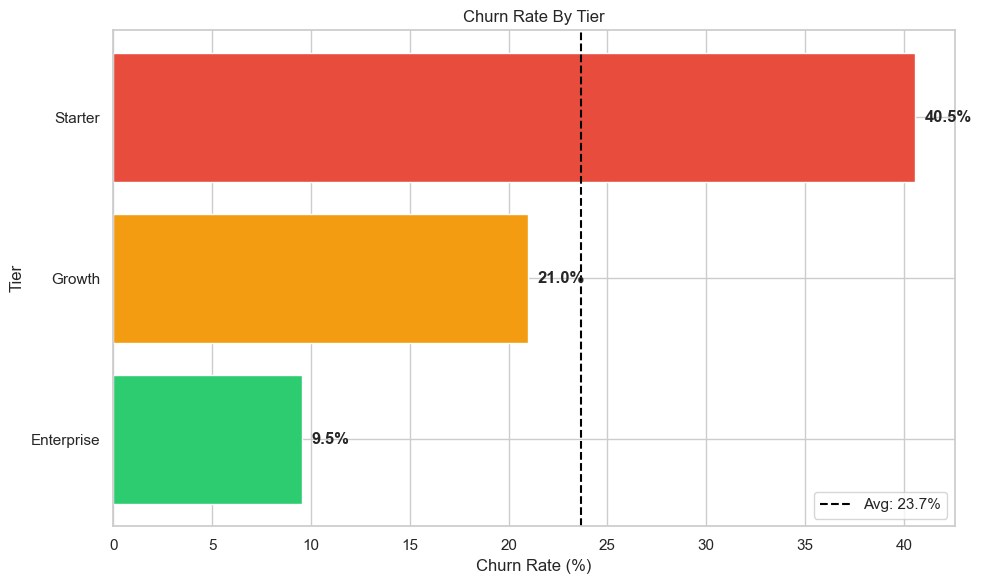

In [13]:
#visualization
churn_by_tier = pysql(query1)

colors = ['#2ecc71', '#f39c12', '#e74c3c']
avg_churn = churn_by_tier['churn_rate'].mean()

bars = plt.barh(churn_by_tier['tier'], churn_by_tier['churn_rate'], color=colors)

#adding data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontweight='bold')

#adding average line 
plt.axvline(avg_churn, color='black', linestyle='--', linewidth=1.5, label=f'Avg: {avg_churn:.1f}%')

plt.xlabel('Churn Rate (%)')
plt.ylabel('Tier')
plt.title('Churn Rate By Tier')
plt.legend()
plt.tight_layout()
plt.show()

- Starter tier shows a 40.5% churn rate, more than 4x the Enterprise rate of 9.5%. 
- This suggests that Starter customers may be struggling with product-market fit or price sensitivity, while Enterprise customers (typically organizations with deeper product integration) tend to stay.
- Worth investigating: whether Starter churn is concentrated in the first 90 days (onboarding failure) or spread over time (value not realized), and whether a pricing or feature adjustment at the entry tier could improve retention.

In [14]:
#Monthly recurring Revenue (MRR) at risk by tier

query2 = """
SELECT tier, SUM(mrr) AS total_mrr,
    SUM(CASE WHEN churned = True THEN mrr END) AS MRR_at_risk,
    ROUND(SUM(CASE WHEN churned = True THEN mrr END) * 1.0 /SUM(mrr) * 100 , 2) AS percentage_MRR_at_risk
FROM df
GROUP BY tier
"""
pysql(query2)

,tier,total_mrr,MRR_at_risk,percentage_MRR_at_risk
0,Enterprise,43953,4186,9.52
1,Growth,29388,6162,20.97
2,Starter,13949,5655,40.54


- Despite Starter tier having the highest churn rate at 40.5%, Growth tier represents the largest revenue risk with USD 6,162 MRR at risk which is 37% more than Starter's USD 5,655.
- This is because Growth customers pay nearly 3x more per month (USD 79 vs USD 29), meaning each lost Growth customer costs significantly more than a lost Starter customer.
- Retention efforts should prioritize Growth tier first, where reducing churn by even a few percentage points would recover more revenue than the same improvement in Starter.

In [15]:
# Average time to churn by tier
query3 = """
SELECT tier, ROUND(AVG((JULIANDAY(churn_date) - JULIANDAY(start_date))), 1) AS avg_time
FROM df
WHERE churned = True
GROUP BY tier
"""
pysql(query3)

,tier,avg_time
0,Enterprise,316.9
1,Growth,243.1
2,Starter,264.5


- Enterprise customers take an average of 316.9 days to churn which is roughly 52 days longer than Starter (264.5 days) and 74 days longer than Growth (243.1 days). This suggests Enterprise customers have deeper product integration and higher switching costs, making them naturally stickier even when they do eventually leave.
- The relatively small 21-day gap between Starter and Growth is notable. Growth customers, despite paying nearly 3x more, churn almost as quickly as Starter. This points to a value perception gap at the Growth tier, where customers may not feel the price increase is justified by the additional features.
- A targeted intervention such as better onboarding, feature education, or a pricing adjustment could meaningfully extend Growth retention.

In [16]:
# Payment failure analysis by churn status
query4 = """
SELECT (CASE WHEN churned = True THEN 'Churned' ELSE 'Non-churned' END) AS customer_type,
    ROUND(AVG(payment_failures), 2) AS avg_payment_failures,
    ROUND(COUNT(CASE WHEN payment_failures > 0 THEN customer_id END) * 1.0 / COUNT(customer_id), 2) AS percent_customers,
    MAX(payment_failures) AS max_payment_failures_recorded
FROM df
GROUP BY churned
"""
pysql(query4)

,customer_type,avg_payment_failures,percent_customers,max_payment_failures_recorded
0,Non-churned,0.63,0.39,5.0
1,Churned,2.38,0.93,5.0


- Churned customers average 2.38 payment failures compared to just 0.63 for active customers which is nearly 4x higher.
- More strikingly, 93% of churned customers experienced at least one payment failure, versus only 39% of active customers. This suggests payment failures are a strong leading indicator of churn, potentially reflecting customer frustration when transactions don't go through smoothly.
- Stripe could reduce churn by implementing proactive interventions at the first or second payment failure, such as smart payment retries, automated dunning emails or prompts to update payment methods before frustration leads to cancellation. 

In [17]:
# Cohort retention analysis 
query5 = """
SELECT STRFTIME('%Y-%m', start_date) as signup_cohort_month, 
    COUNT(customer_id) as total_customers,
    COUNT(CASE WHEN churned = False THEN customer_id END) as active_customers,
    ROUND(COUNT(CASE WHEN churned = False THEN customer_id END) * 1.0 / COUNT(customer_id), 2) AS retention_rate
FROM df
GROUP BY STRFTIME('%Y-%m', start_date)
ORDER BY STRFTIME('%Y-%m', start_date) ASC;
"""
pysql(query5)


,signup_cohort_month,total_customers,active_customers,retention_rate
0,2023-01,53,41,0.77
1,2023-02,56,39,0.70
2,2023-03,53,38,0.72
3,2023-04,58,34,0.59
4,2023-05,77,53,0.69
5,2023-06,60,43,0.72
6,2023-07,63,43,0.68
7,2023-08,45,34,0.76
8,2023-09,46,40,0.87
9,2023-10,56,35,0.63


- Retention rates across cohorts range from 59% to 87% with most months staying above 65%.
- The September 2023 cohort had the strongest retention at 87%, while April 2023 was the weakest at 59%.
- Notably retention dipped again in October 2023 from 87% to 63% before recovering through year-end, suggesting possible seasonal or product-related fluctuations worth investigating.
- Newer cohorts such as June 2024 show an 80% retention rate, but this likely reflects limited time to churn rather than genuine improvement, including them in strategy decisions could be misleading.
- To understand why the April 2023 cohort underperformed, the next step would be to examine their tier distribution, payment failure rates, and feature usage scores, a high concentration of Starter customers or elevated payment failures in that cohort could explain the drop.

In [18]:
#visualization 

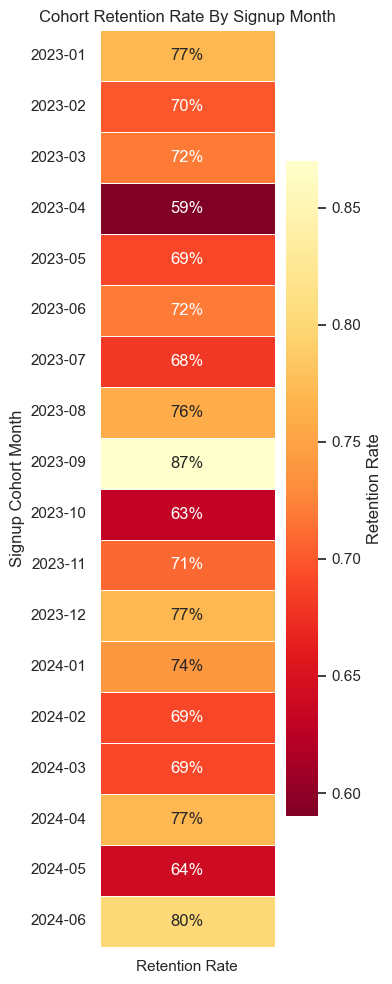

In [19]:
cohort_data = pysql(query5)

cohort_heatmap = cohort_data[['signup_cohort_month', 'retention_rate']].set_index('signup_cohort_month')
cohort_heatmap.columns = ['Retention Rate']

plt.figure(figsize=(4, 10))

sns.heatmap(cohort_heatmap, annot=True, fmt='.0%', cmap='YlOrRd_r', linewidth=0.5,
            cbar_kws={'label': 'Retention Rate'})

plt.title('Cohort Retention Rate By Signup Month')
plt.xlabel('')
plt.ylabel('Signup Cohort Month')
plt.tight_layout()
plt.show()

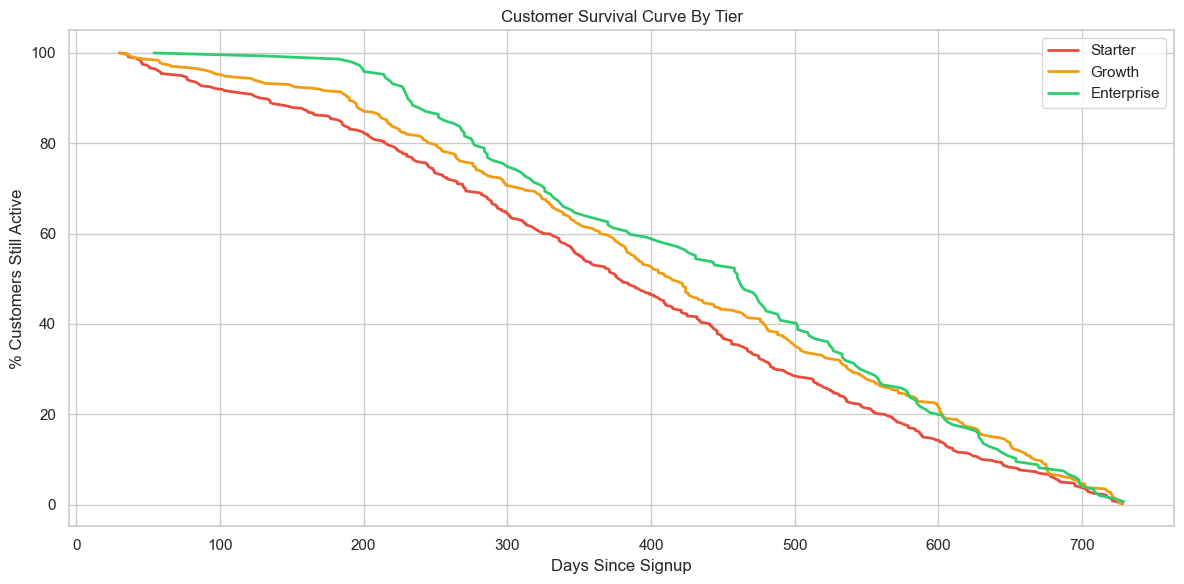

In [20]:
# Survival curve by tier
#1. calculating survival days for every customer

analysis_end_date = pd.Timestamp('2024-12-31')

df['survival_days'] = df.apply(
    lambda row: (row['churn_date'] - row['start_date']).days
    if row['churned']
    else (analysis_end_date - row['start_date']).days,
    axis=1
)

tier_colors = {
    'Starter': '#e74c3c',
    'Growth': '#f39c12',
    'Enterprise': '#2ecc71'
}

plt.figure(figsize=(12, 6))

for tier in ['Starter', 'Growth', 'Enterprise']:
    tier_df = df[df['tier'] == tier].sort_values('survival_days')
    total = len(tier_df)
    #calculating survival rate at each day
    survival_rates = [(1 - i/total) * 100 for i in range(total)]

    plt.plot(tier_df['survival_days'].values, survival_rates, label=tier, 
             color=tier_colors[tier], linewidth=2)

plt.xlabel('Days Since Signup')
plt.ylabel('% Customers Still Active')
plt.title('Customer Survival Curve By Tier')
plt.legend()
plt.tight_layout()
plt.show()

- The survival curve reveals a clear divergence in early retention across tiers.
- Enterprise customers remain almost fully stable for the first 130 days before gradually declining, suggesting strong initial product integration and higher switching costs that delay churn.
- In contrast, Starter and Growth customers begin churning before day 50, pointing to an onboarding gap where customers leave before realizing the product's full value.
- Note that all curves converge near zero at day 700 because active customers' survival days are capped at the analysis end date (December 31, 2024), not because all customers actually churned.
- To reduce early churn in Starter and Growth tiers, Stripe should consider a structured onboarding program in the first 30 days, guided setup, feature walkthroughs, and proactive check-ins.
- Combined with payment failure findings from the earlier analysis, early outreach at the first payment failure could further prevent the frustration that drives customers to cancel in those critical first 50 days.

In [24]:
query6 = """
SELECT COUNT(customer_id) AS churned_customers
FROM df 
WHERE churned = True
"""
pysql(query6)




,churned_customers
0,287
